In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [12]:
df = pd.read_csv('attacks.csv', encoding='latin-1')

print(df.shape)
print(df.head())
print(df.columns.tolist())
print(df.dtypes)

(25723, 24)
  Case Number         Date    Year        Type    Country             Area  \
0  2018.06.25  25-Jun-2018  2018.0     Boating        USA       California   
1  2018.06.18  18-Jun-2018  2018.0  Unprovoked        USA          Georgia   
2  2018.06.09  09-Jun-2018  2018.0     Invalid        USA           Hawaii   
3  2018.06.08  08-Jun-2018  2018.0  Unprovoked  AUSTRALIA  New South Wales   
4  2018.06.04  04-Jun-2018  2018.0    Provoked     MEXICO           Colima   

                         Location     Activity             Name Sex   ...  \
0     Oceanside, San Diego County     Paddling      Julie Wolfe    F  ...   
1  St. Simon Island, Glynn County     Standing  Adyson McNeely     F  ...   
2                    Habush, Oahu      Surfing      John Denges    M  ...   
3              Arrawarra Headland      Surfing             male    M  ...   
4                        La Ticla  Free diving   Gustavo Ramos     M  ...   

          Species           Investigator or Source      

In [13]:
# Keep only useful columns
cols = ['Year', 'Country', 'Activity', 'Sex ', 'Age', 'Time', 'Species ', 'Fatal (Y/N)']
df = df[cols]

# Rename columns to remove spaces
df.columns = ['Year', 'Country', 'Activity', 'Sex', 'Age', 'Time', 'Species', 'Fatal']

# Clean the target column — keep only Y or N
df = df[df['Fatal'].isin(['Y', 'N'])]

# Convert Age to numeric (some entries are text)
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Clean Sex column
df['Sex'] = df['Sex'].str.strip().str.upper()
df = df[df['Sex'].isin(['M', 'F'])]

# Drop rows missing too many key fields
df = df.dropna(subset=['Activity', 'Country'])

print(df.shape)
print(df['Fatal'].value_counts())

(4901, 8)
Fatal
N    3727
Y    1174
Name: count, dtype: int64


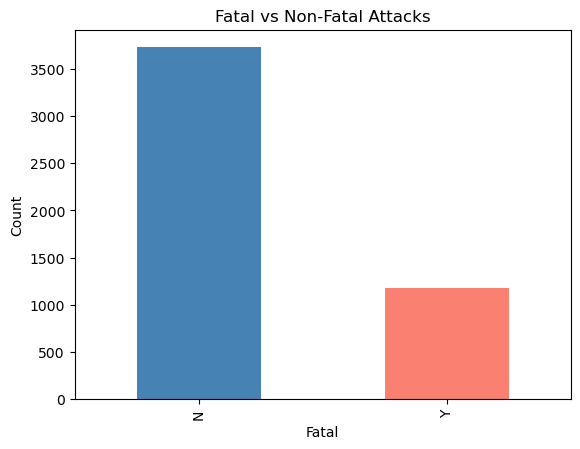

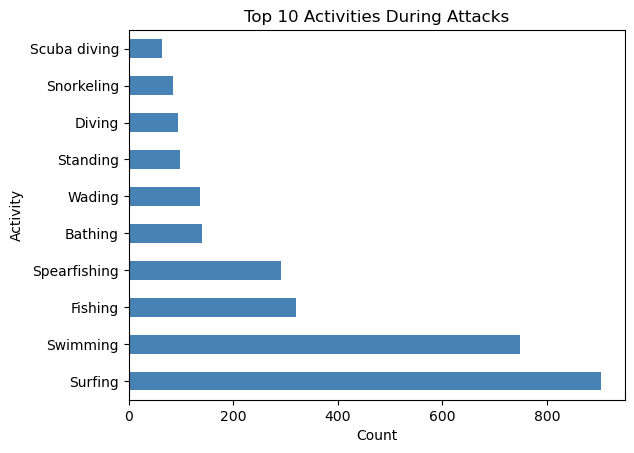

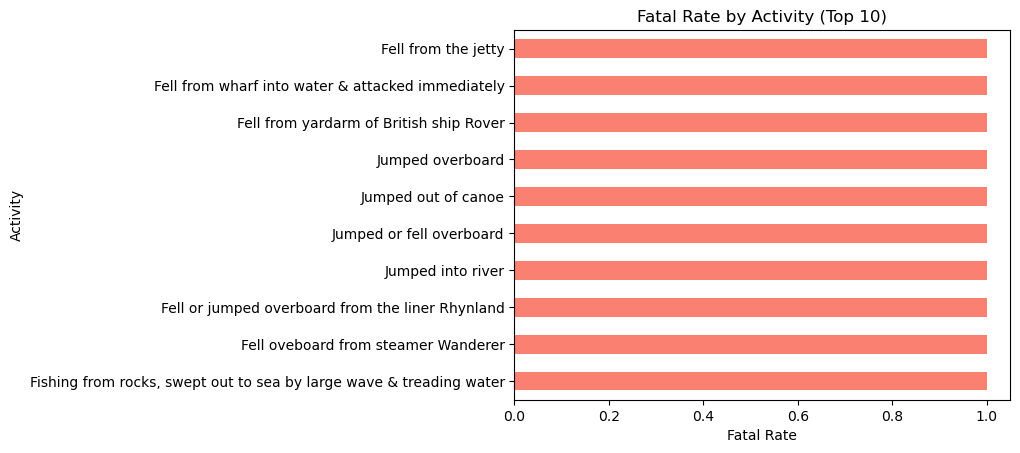

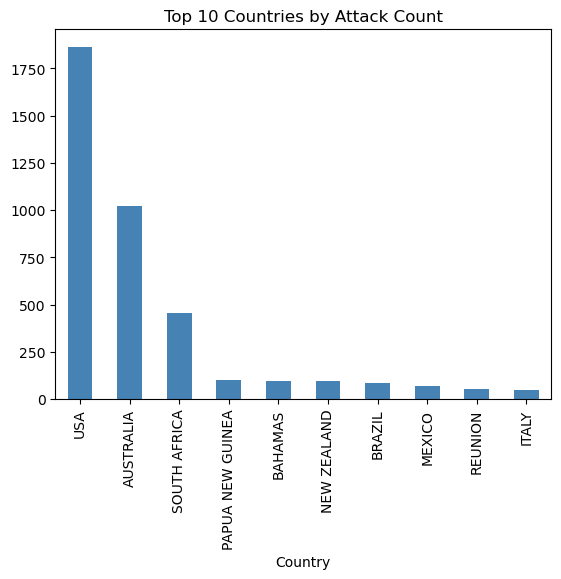

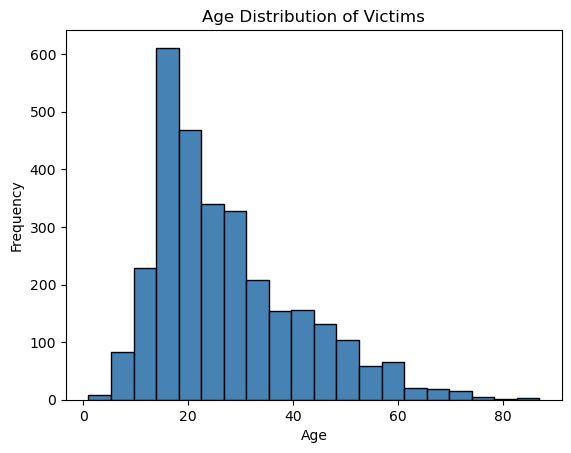

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Fatal vs Non-Fatal counts
df['Fatal'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Fatal vs Non-Fatal Attacks')
plt.xlabel('Fatal')
plt.ylabel('Count')
plt.show()

# 2. Top 10 activities
top_activities = df['Activity'].value_counts().head(10)
top_activities.plot(kind='barh', color='steelblue')
plt.title('Top 10 Activities During Attacks')
plt.xlabel('Count')
plt.show()

# 3. Fatal rate by activity
activity_fatal = df.groupby('Activity')['Fatal'].apply(lambda x: (x == 'Y').sum() / len(x))
activity_fatal = activity_fatal.sort_values(ascending=False).head(10)
activity_fatal.plot(kind='barh', color='salmon')
plt.title('Fatal Rate by Activity (Top 10)')
plt.xlabel('Fatal Rate')
plt.show()

# 4. Top 10 countries
df['Country'].value_counts().head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 Countries by Attack Count')
plt.xlabel('Country')
plt.show()

# 5. Age distribution
df['Age'].dropna().plot(kind='hist', bins=20, color='steelblue', edgecolor='black')
plt.title('Age Distribution of Victims')
plt.xlabel('Age')
plt.show()

In [16]:
from sklearn.preprocessing import LabelEncoder

# Select features
features = ['Activity', 'Country', 'Sex', 'Age']
target = 'Fatal'

model_df = df[features + [target]].dropna()

# Encode categorical columns
le = LabelEncoder()
model_df['Activity'] = le.fit_transform(model_df['Activity'])
model_df['Country'] = le.fit_transform(model_df['Country'])
model_df['Sex'] = le.fit_transform(model_df['Sex'])
model_df['Fatal'] = (model_df['Fatal'] == 'Y').astype(int)

X = model_df[features]
y = model_df[target]

print(X.shape)
print(y.value_counts())

(3006, 4)
Fatal
0    2447
1     559
Name: count, dtype: int64


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"\n--- {name} ---")
    print(f"Accuracy: {accuracy_score(y_test, preds):.3f}")
    print(f"F1 Score: {f1_score(y_test, preds):.3f}")
    print(classification_report(y_test, preds))


--- Logistic Regression ---
Accuracy: 0.804
F1 Score: 0.000
              precision    recall  f1-score   support

           0       0.80      1.00      0.89       484
           1       0.00      0.00      0.00       118

    accuracy                           0.80       602
   macro avg       0.40      0.50      0.45       602
weighted avg       0.65      0.80      0.72       602


--- Decision Tree ---
Accuracy: 0.739
F1 Score: 0.379
              precision    recall  f1-score   support

           0       0.85      0.82      0.83       484
           1       0.36      0.41      0.38       118

    accuracy                           0.74       602
   macro avg       0.60      0.61      0.61       602
weighted avg       0.75      0.74      0.75       602



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



--- Random Forest ---
Accuracy: 0.781
F1 Score: 0.333
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       484
           1       0.41      0.28      0.33       118

    accuracy                           0.78       602
   macro avg       0.62      0.59      0.60       602
weighted avg       0.75      0.78      0.76       602



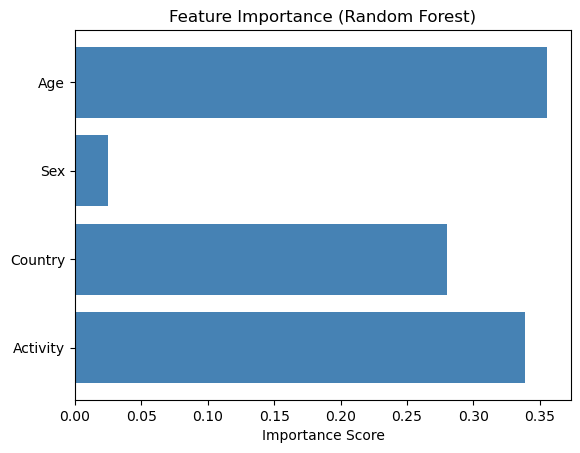

In [18]:
import numpy as np

rf_model = models['Random Forest']
importances = rf_model.feature_importances_

plt.barh(features, importances, color='steelblue')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.show()

      Activity  Country  Sex   Age  Risk Score  Actual Fatal
2705       608        6    1  62.0    0.930000             1
4605       518      100    1  18.0    0.927500             0
3152       610        6    1  32.0    0.910000             0
3356       517       24    1  34.0    0.900000             1
2258       517        6    0  21.0    0.890000             0
4658       517      100    1  26.0    0.872968             1
1202       517        6    1  43.0    0.870000             0
3789       406       84    1   1.0    0.870000             1
4502       517        6    1  21.0    0.860000             0
4132       517        6    1  21.0    0.860000             1


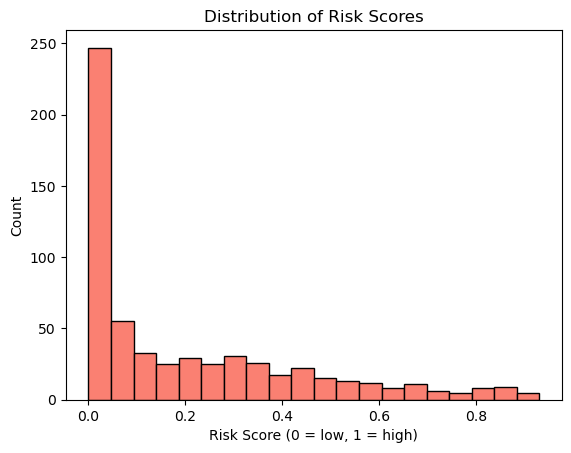

In [19]:
# Use predicted probabilities from Random Forest as the risk score
rf_probs = rf_model.predict_proba(X_test)[:, 1]  # probability of fatal

# Add back to a results dataframe
results = X_test.copy()
results['Risk Score'] = rf_probs
results['Actual Fatal'] = y_test.values

# Show high-risk cases
print(results.sort_values('Risk Score', ascending=False).head(10))

# Visualize score distribution
plt.hist(rf_probs, bins=20, color='salmon', edgecolor='black')
plt.title('Distribution of Risk Scores')
plt.xlabel('Risk Score (0 = low, 1 = high)')
plt.ylabel('Count')
plt.show()